# CIFAR10 with CNNs
Simple starter notebook to benchmark your own CNN with PyTorch on the CIFAR-10 dataset.

OBS.:

- The main code is basically done, so focus on training the models and searching for the best hyperparameters and architectures.
- You are not required to use this exact code or even the PyTorch library.
- It is recommended to use execution environments with GPU access (such as Google Colab), since larger models will take more time to train.
- Remember to document the history of your experiments and which results motivated the changes in subsequent experiments.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
pip install optuna -q

In [14]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold, train_test_split
from torch.utils.data import DataLoader, Subset

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda


In [16]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)


In [17]:
subset_size = 10000 # subconjunto pra ir mais rápido

train_indices = list(range(len(train_dataset)))
train_labels = [train_dataset[i][1] for i in train_indices]

search_indices, _ = train_test_split(
    train_indices,
    train_size=subset_size,
    stratify=train_labels, # garante a mesma quantidade por classe
    random_state=42
)

search_dataset = Subset(train_dataset, search_indices) # só no optuna

print(f"Subconjunto de busca criado com {len(search_dataset)} imagens.")
print(f"Representa {len(search_dataset)//10} imagens por classe.")

Subconjunto de busca criado com 10000 imagens.
Representa 1000 imagens por classe.


In [18]:
def final_evaluation_cnn(best_model, test_loader):
    best_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device) # Usa o dispositivo dinâmico
            outputs = best_model(images)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nRelatório de Classificação Final:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.title('Matriz de Confusão - CNN')
    plt.show()

In [19]:
class CNN(nn.Module):
    def __init__(self, conv_filters, kernel_size, fc_size, dropout_rate, activation_func):
        super(CNN, self).__init__()

        pad = kernel_size // 2
        self.activation = activation_func

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=conv_filters[0], kernel_size=kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm2d(conv_filters[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=conv_filters[0], out_channels=conv_filters[1], kernel_size=kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm2d(conv_filters[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=conv_filters[1], out_channels=conv_filters[2], kernel_size=kernel_size, padding=pad)
        self.bn3 = nn.BatchNorm2d(conv_filters[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(dropout_rate)

        flattened_size = conv_filters[2] * 4 * 4

        self.fc1 = nn.Linear(flattened_size, fc_size)
        self.fc2 = nn.Linear(fc_size, 10)

    def forward(self, x):
        x = self.pool1(self.activation(self.bn1(self.conv1(x))))
        x = self.pool2(self.activation(self.bn2(self.conv2(x))))
        x = self.pool3(self.activation(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = self.dropout(self.activation(self.fc1(x)))
        x = self.fc2(x)
        return x

In [20]:
def objective_cnn(trial):
    conv_arch_dict = {
        "Pequena": (32, 64, 128),
        "Media": (64, 128, 256),
        "Crescente": (32, 128, 512)
    }

    arch_name = trial.suggest_categorical("conv_arch", list(conv_arch_dict.keys()))
    conv_filters = conv_arch_dict[arch_name]

    kernel_size = trial.suggest_categorical("kernel_size", [3, 5])
    fc_size = trial.suggest_categorical("fc_size", [128, 256, 512])

    dropout_rate = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    activation_name = trial.suggest_categorical("activation", ["ReLU", "Tanh", "LeakyReLU"])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    activations = {
        "ReLU": nn.ReLU(),
        "Tanh": nn.Tanh(),
        "LeakyReLU": nn.LeakyReLU()
    }

    print(f"\nIniciando Trial CNN #{trial.number}")
    print(f"Arquitetura: {arch_name} Filtros: {conv_filters} | Kernel: {kernel_size}")
    print(f"Otimizador: {optimizer_name} | Ativação: {activation_name} | LR: {lr:.5f}")

    k_folds = 3
    kfold = KFold(n_splits=k_folds, shuffle=True)
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(search_dataset)):
        train_sub = Subset(search_dataset, train_ids)
        val_sub = Subset(search_dataset, val_ids)
        t_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        v_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False)

        # Usando .to(device) em vez de .cuda()
        model = CNN(conv_filters, kernel_size, fc_size, dropout_rate, activations[activation_name]).to(device)
        optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)

        for epoch in range(5):
            model.train()
            for images, labels in t_loader:
                # Usando .to(device)
                images = images.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = nn.CrossEntropyLoss()(outputs, labels)
                loss.backward()
                optimizer.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in v_loader:
                # Usando .to(device)
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                pred = outputs.argmax(dim=1)
                correct += pred.eq(labels).sum().item()

        acc = correct / len(val_ids)
        fold_accuracies.append(acc)

    mean_accuracy = np.mean(fold_accuracies)
    print(f"RESULTADO TRIAL CNN #{trial.number}: Acurácia Média (CV) = {mean_accuracy:.4f}")

    return mean_accuracy

In [21]:
study_cnn = optuna.create_study(direction="maximize")
study_cnn.optimize(objective_cnn, n_trials=100)

print(f"\nMelhor Acurácia de Validação CNN: {study_cnn.best_value:.4f}")
print(f"Melhores Parâmetros CNN: {study_cnn.best_params}")

[I 2026-03-28 16:14:16,971] A new study created in memory with name: no-name-50e75b00-5af4-4546-8c86-6bc8c26b3953



Iniciando Trial CNN #0
Arquitetura: Media Filtros: (64, 128, 256) | Kernel: 5
Otimizador: SGD | Ativação: Tanh | LR: 0.00412


[I 2026-03-28 16:14:53,777] Trial 0 finished with value: 0.4764015693710943 and parameters: {'conv_arch': 'Media', 'kernel_size': 5, 'fc_size': 512, 'dropout': 0.0550577443977292, 'lr': 0.004121580923367968, 'weight_decay': 0.0004435610594556644, 'activation': 'Tanh', 'optimizer': 'SGD', 'batch_size': 32}. Best is trial 0 with value: 0.4764015693710943.


RESULTADO TRIAL CNN #0: Acurácia Média (CV) = 0.4764

Iniciando Trial CNN #1
Arquitetura: Pequena Filtros: (32, 64, 128) | Kernel: 5
Otimizador: Adam | Ativação: LeakyReLU | LR: 0.00095


[I 2026-03-28 16:15:24,587] Trial 1 finished with value: 0.5846972219717473 and parameters: {'conv_arch': 'Pequena', 'kernel_size': 5, 'fc_size': 256, 'dropout': 0.14643386750316373, 'lr': 0.0009459457350867646, 'weight_decay': 2.335734835720712e-06, 'activation': 'LeakyReLU', 'optimizer': 'Adam', 'batch_size': 64}. Best is trial 1 with value: 0.5846972219717473.


...

RESULTADO TRIAL CNN #97: Acurácia Média (CV) = 0.6323

Iniciando Trial CNN #98
Arquitetura: Pequena Filtros: (32, 64, 128) | Kernel: 3
Otimizador: Adam | Ativação: Tanh | LR: 0.00041


[I 2026-03-28 17:19:17,033] Trial 98 finished with value: 0.5773989816498146 and parameters: {'conv_arch': 'Pequena', 'kernel_size': 3, 'fc_size': 128, 'dropout': 0.1140402680937539, 'lr': 0.000405322658363532, 'weight_decay': 0.0007671677765469358, 'activation': 'Tanh', 'optimizer': 'Adam', 'batch_size': 32}. Best is trial 31 with value: 0.6519013329047362.


RESULTADO TRIAL CNN #98: Acurácia Média (CV) = 0.5774

Iniciando Trial CNN #99
Arquitetura: Media Filtros: (64, 128, 256) | Kernel: 5
Otimizador: Adam | Ativação: ReLU | LR: 0.00028


[I 2026-03-28 17:19:50,699] Trial 99 finished with value: 0.6059986622537479 and parameters: {'conv_arch': 'Media', 'kernel_size': 5, 'fc_size': 512, 'dropout': 0.07528797887993871, 'lr': 0.0002824889830966632, 'weight_decay': 0.00044419901662902297, 'activation': 'ReLU', 'optimizer': 'Adam', 'batch_size': 64}. Best is trial 31 with value: 0.6519013329047362.


RESULTADO TRIAL CNN #99: Acurácia Média (CV) = 0.6060

Melhor Acurácia de Validação CNN: 0.6519
Melhores Parâmetros CNN: {'conv_arch': 'Media', 'kernel_size': 3, 'fc_size': 512, 'dropout': 0.0027747134735172374, 'lr': 0.00029211807238642873, 'weight_decay': 9.977585184128647e-06, 'activation': 'ReLU', 'optimizer': 'Adam', 'batch_size': 32}


In [22]:
best_params = study_cnn.best_params

conv_arch_dict = {
    "Pequena": (32, 64, 128),
    "Media": (64, 128, 256),
    "Crescente": (32, 128, 512)
}
activations = {
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU()
}

best_conv_filters = conv_arch_dict[best_params["conv_arch"]]
best_activation = activations[best_params["activation"]]

print(f"\nTreinando o modelo CNN final com todo o dataset de treino...")

# Instanciando com os melhores parâmetros
best_cnn_model = CNN(
    conv_filters=best_conv_filters,
    kernel_size=best_params["kernel_size"],
    fc_size=best_params["fc_size"],
    dropout_rate=best_params["dropout"],
    activation_func=best_activation
).to(device) # Usando .to(device)

optimizer = getattr(torch.optim, best_params["optimizer"])(
    best_cnn_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

full_train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)

best_loss = float('inf')
patience = 5
patience_counter = 0
max_epochs = 50
best_model_path = '/content/drive/MyDrive/melhor_modelo_cnn_final.pth'

for epoch in range(max_epochs):
    best_cnn_model.train()
    epoch_loss = 0.0

    for images, labels in tqdm(full_train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False):
        # Usando .to(device)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = best_cnn_model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(full_train_loader)
    print(f"Época {epoch+1} finalizada. Loss Média: {avg_epoch_loss:.4f}")

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save(best_cnn_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly Stopping ativado na época {epoch+1}.")
            break


Treinando o modelo CNN final com todo o dataset de treino...


Época 1 finalizada. Loss Média: 1.1310


Época 2 finalizada. Loss Média: 0.7742


Época 3 finalizada. Loss Média: 0.6293


Época 4 finalizada. Loss Média: 0.5246


...

Época 46 finalizada. Loss Média: 0.0202


Época 47 finalizada. Loss Média: 0.0207


Época 48 finalizada. Loss Média: 0.0199


Época 49 finalizada. Loss Média: 0.0179


Época 50 finalizada. Loss Média: 0.0182

Early Stopping ativado na época 50.



Avaliação no conjunto de testes:

Relatório de Classificação Final:
              precision    recall  f1-score   support

    airplane       0.90      0.73      0.81      1000
  automobile       0.90      0.89      0.90      1000
        bird       0.73      0.75      0.74      1000
         cat       0.56      0.74      0.64      1000
        deer       0.79      0.75      0.77      1000
         dog       0.72      0.67      0.70      1000
        frog       0.81      0.89      0.85      1000
       horse       0.91      0.76      0.83      1000
        ship       0.83      0.92      0.88      1000
       truck       0.90      0.82      0.86      1000

    accuracy                           0.79     10000
   macro avg       0.80      0.79      0.80     10000
weighted avg       0.80      0.79      0.80     10000



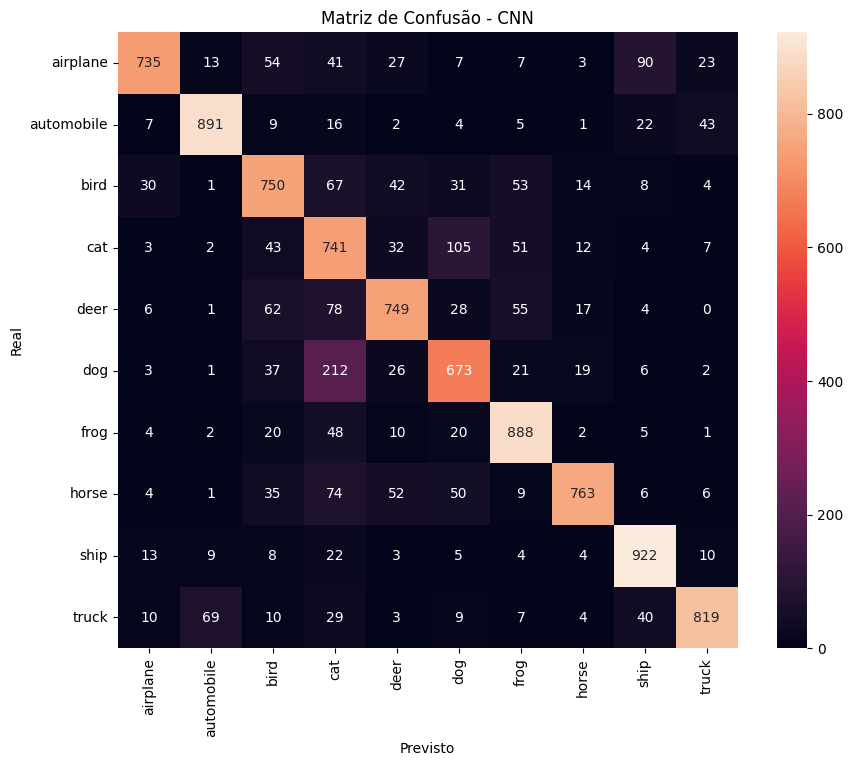

In [23]:
print("\nAvaliação no conjunto de testes:")
best_cnn_model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

final_evaluation_cnn(best_cnn_model, test_loader)